In [1]:
import numpy as np

espace_latent = 5

## Générateur

In [2]:
from keras.models import Model
from keras.layers import Dense, Input
from keras import activations, losses, optimizers, initializers, metrics

In [3]:
gen_input = Input(shape = (espace_latent,))
gen_x1 = Dense(15, kernel_initializer=initializers.he_uniform, activation=activations.relu)(gen_input)
gen_output = Dense(2)(gen_x1)

generateur = Model(gen_input, gen_output)

## Classifieur

In [4]:
class_input = Input(shape = (2,))
class_x1 = Dense(25, kernel_initializer=initializers.he_uniform, activation=activations.relu)(class_input)
class_output = Dense(1, activation=activations.sigmoid)(class_x1)

classifieur = Model(class_input, class_output)

classifieur.compile(optimizer=optimizers.Adam(), loss=losses.binary_crossentropy, metrics=[metrics.Accuracy])

## GAN

In [5]:
gan = Model(gen_input, classifieur(generateur(gen_input)))
gan.compile(optimizer=optimizers.Adam(), loss=losses.binary_crossentropy, metrics=[metrics.Accuracy])

In [6]:
def generate_real_sample(n_input, min_range=-0.5, max_range=0.5):
    X = np.random.uniform(min_range, max_range, size=(n_input, 1))
    X = np.hstack([X, X**2])
    
    y = np.ones(shape=(n_input, 1))

    return X, y

In [7]:
def generate_fake_sample(generateur : Model, latent_dim, n_input):
    X = np.random.normal(0, 1, size=(n_input, latent_dim))
    y_gen = generateur.predict(x=X, verbose=0)
    
    y_label = np.zeros(shape=(n_input, 1))

    return y_gen, y_label

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


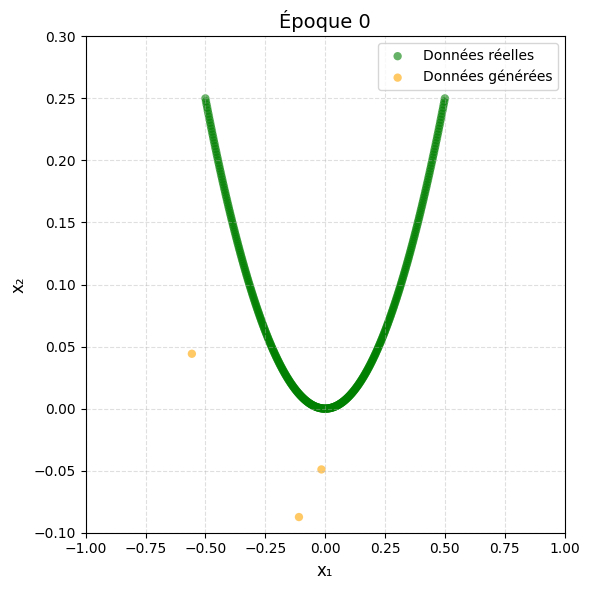

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


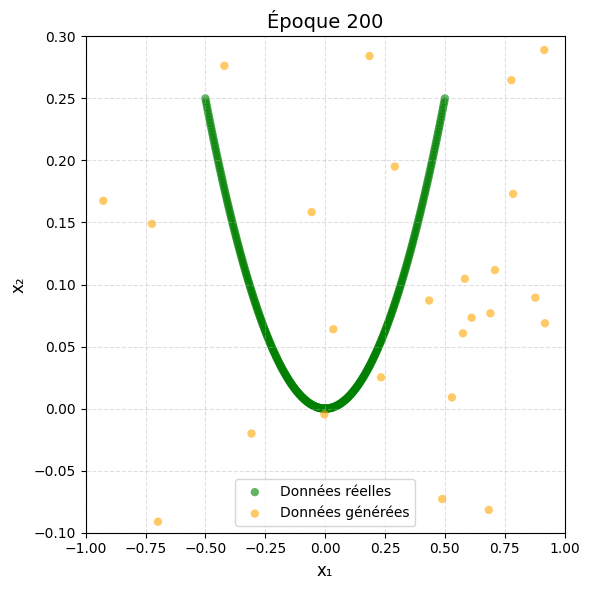

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


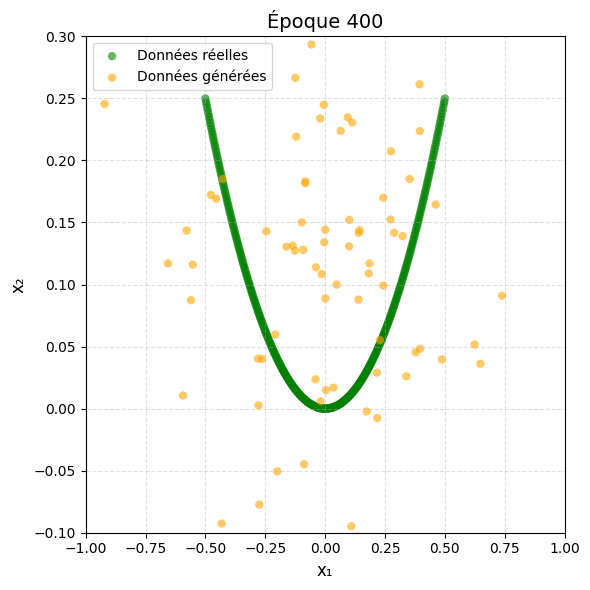

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


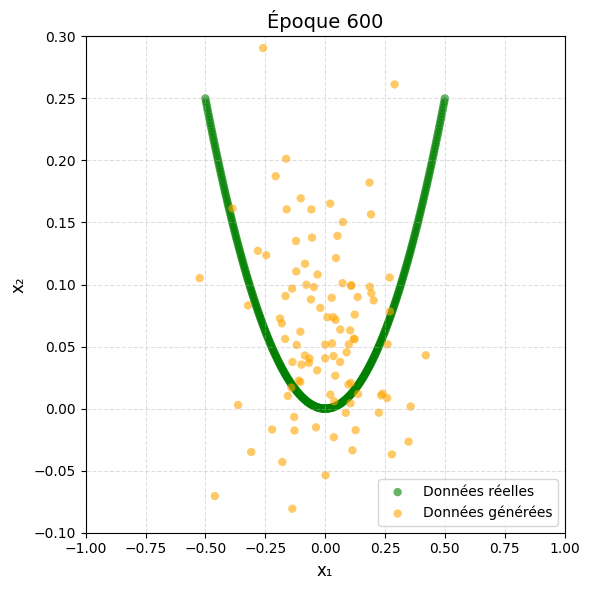

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


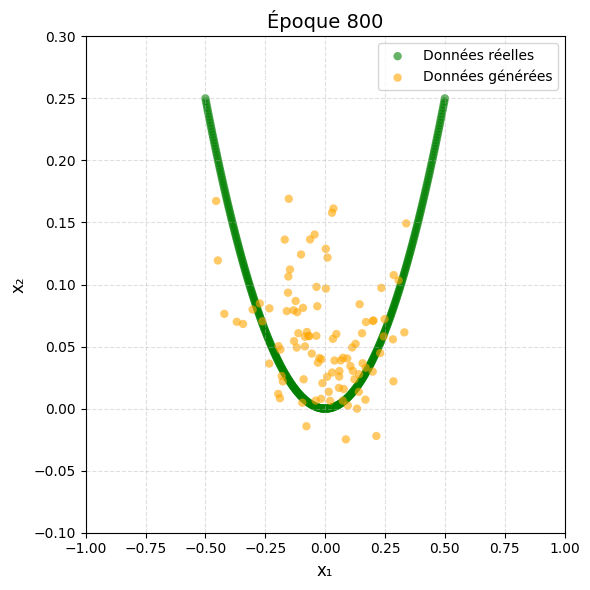

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


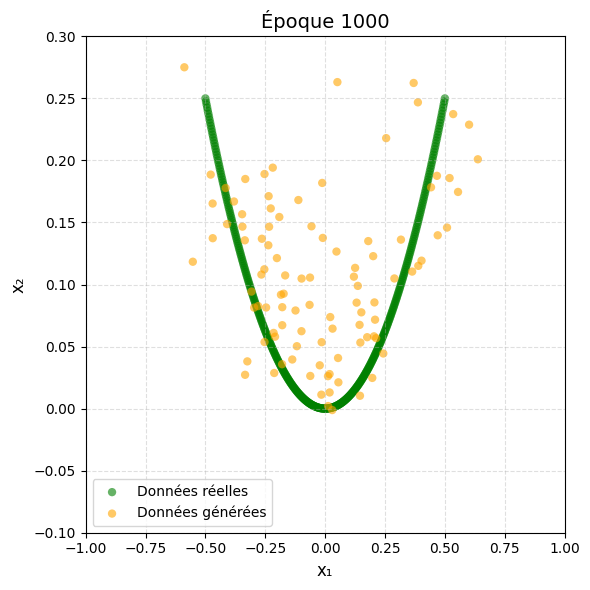

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


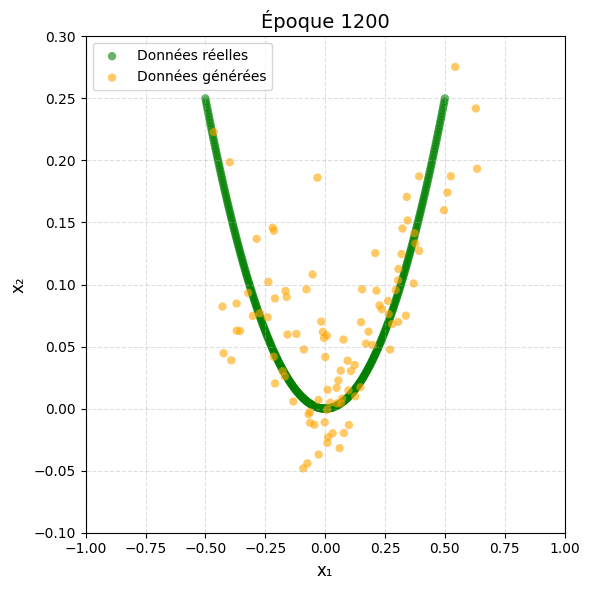

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 961us/step


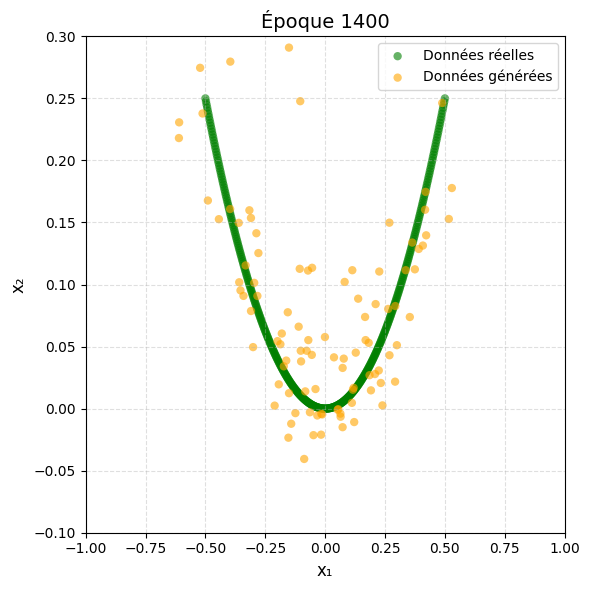

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


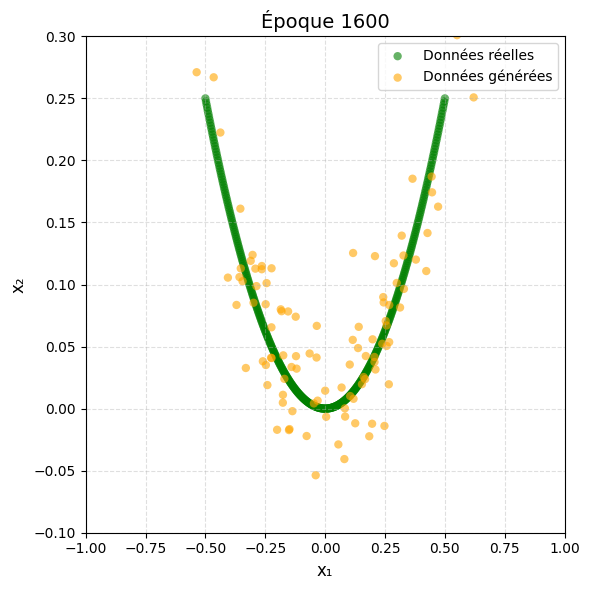

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


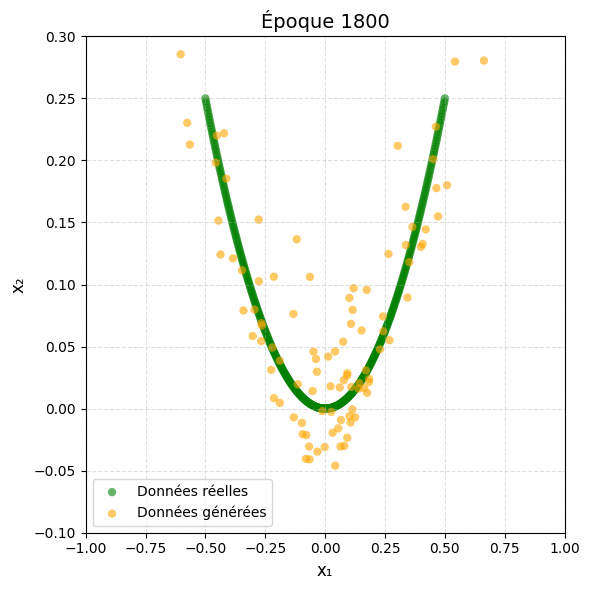

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


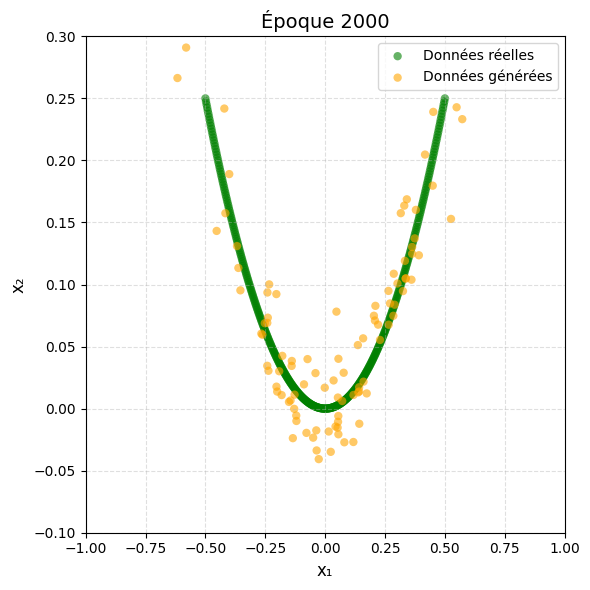

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


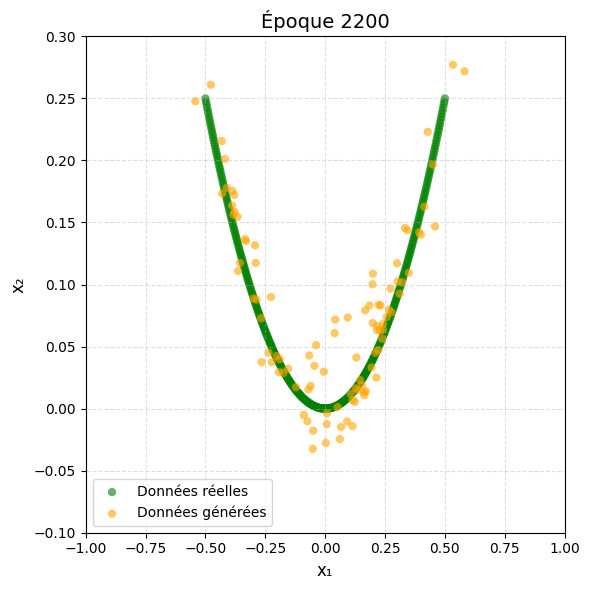

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


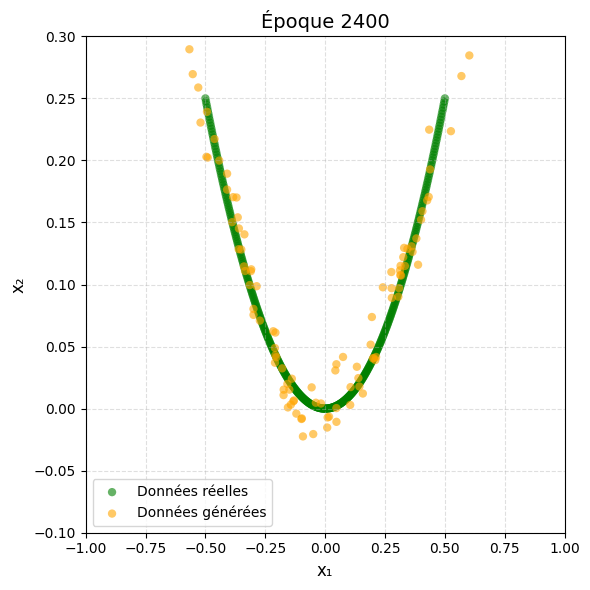

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


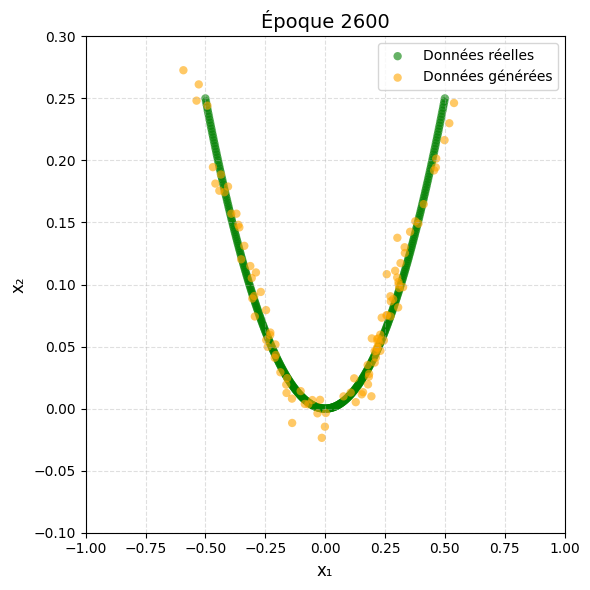

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


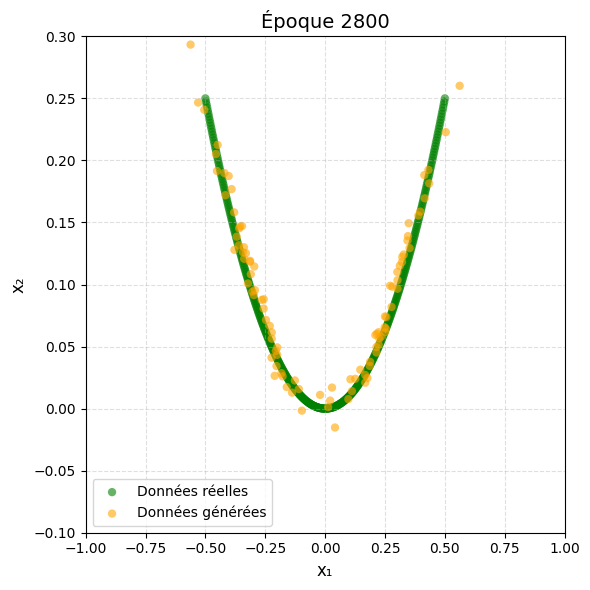

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


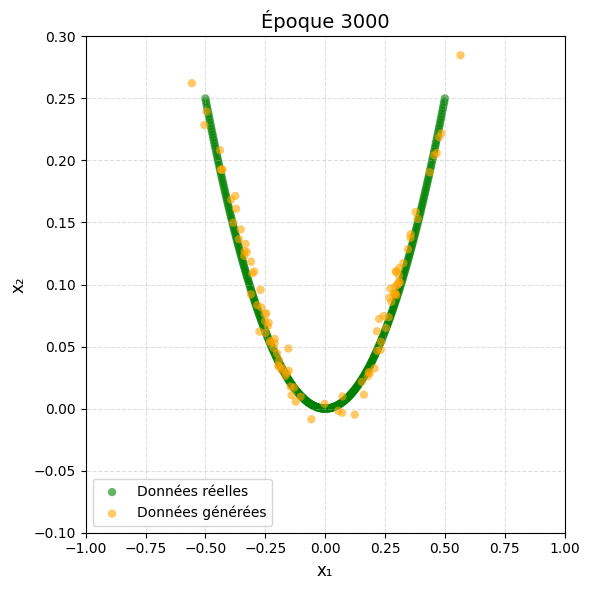

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


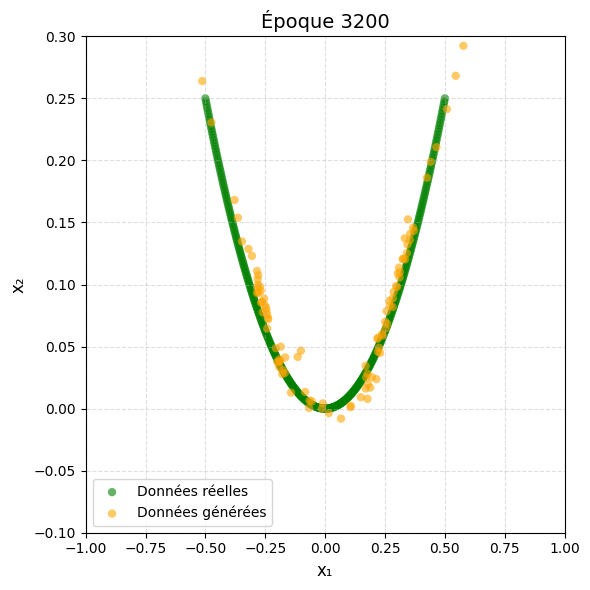

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


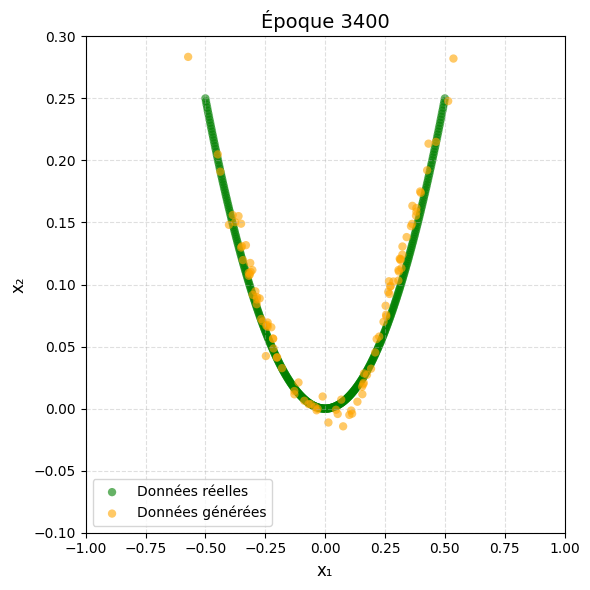

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


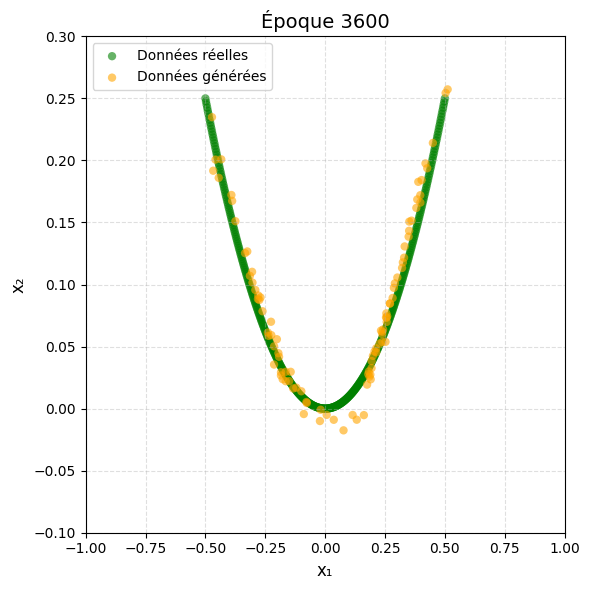

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


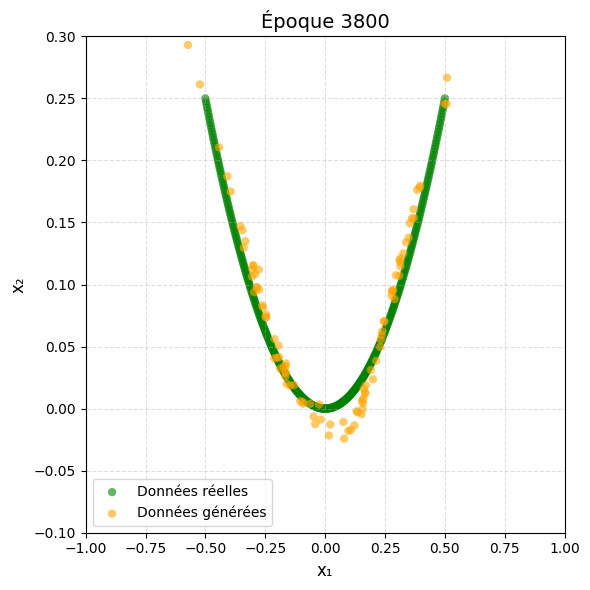

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


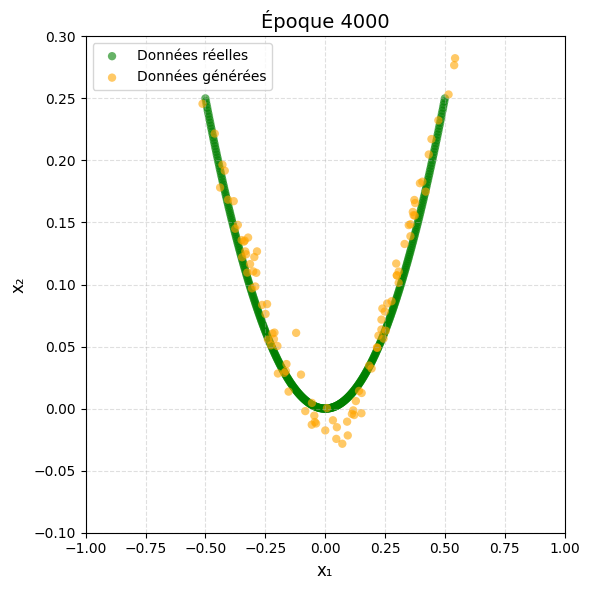

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step  


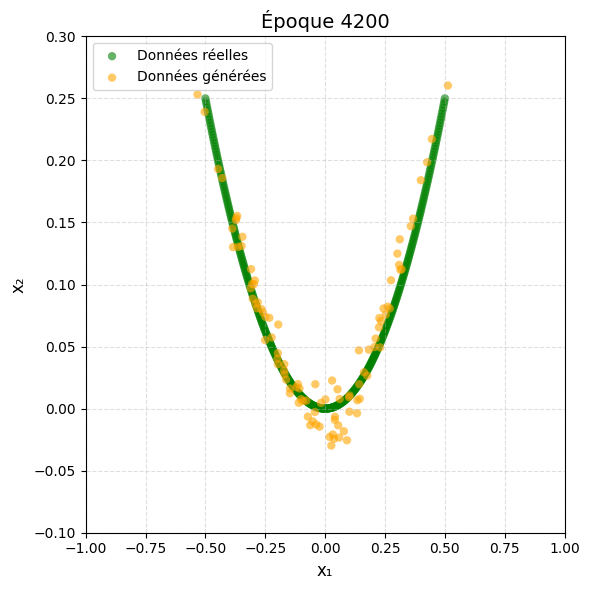

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


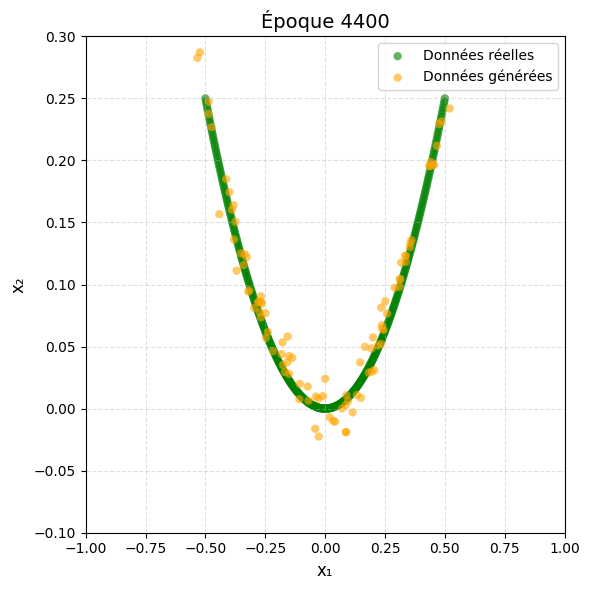

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


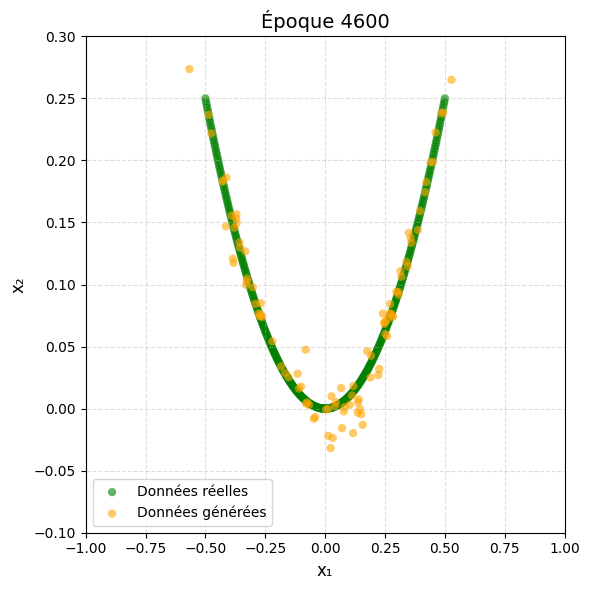

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 771us/step


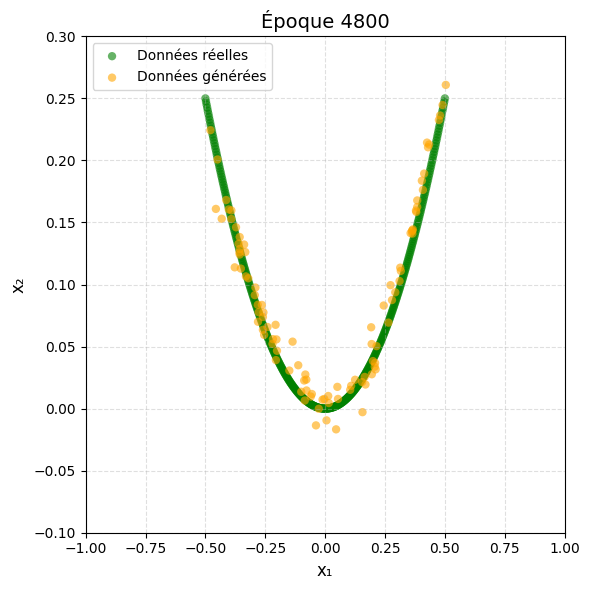

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


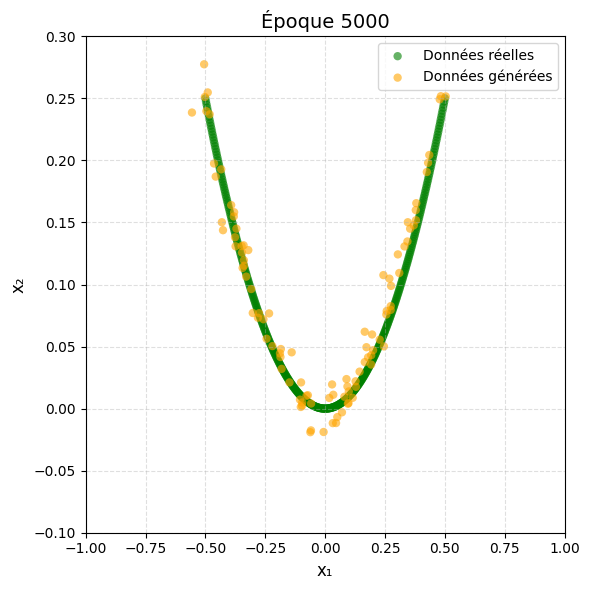

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step  


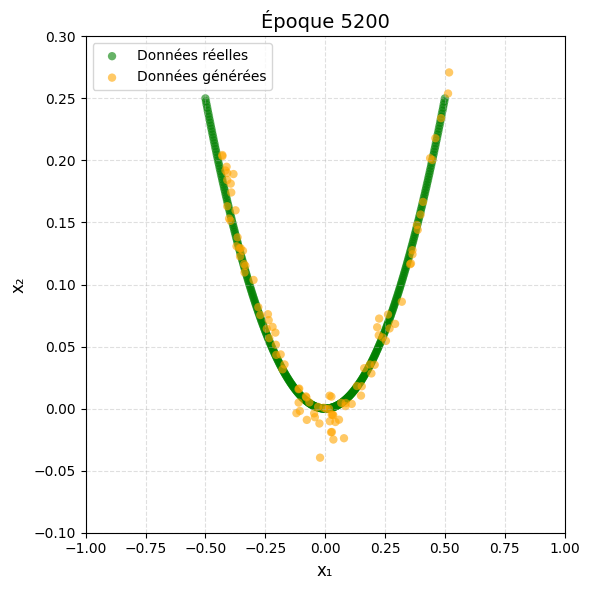

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


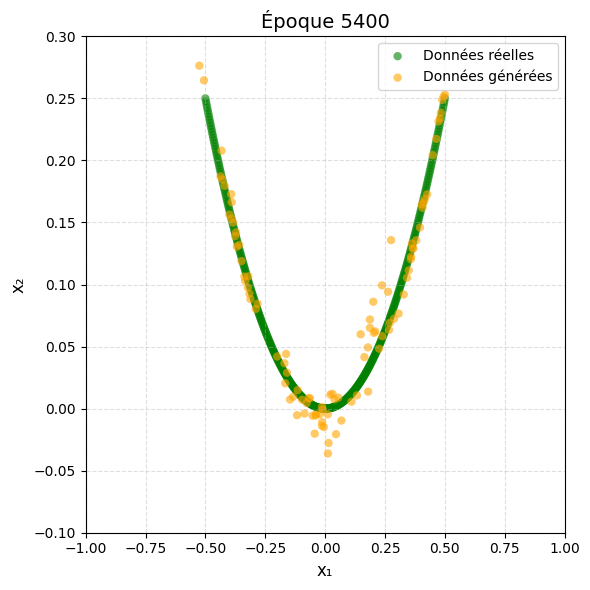

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


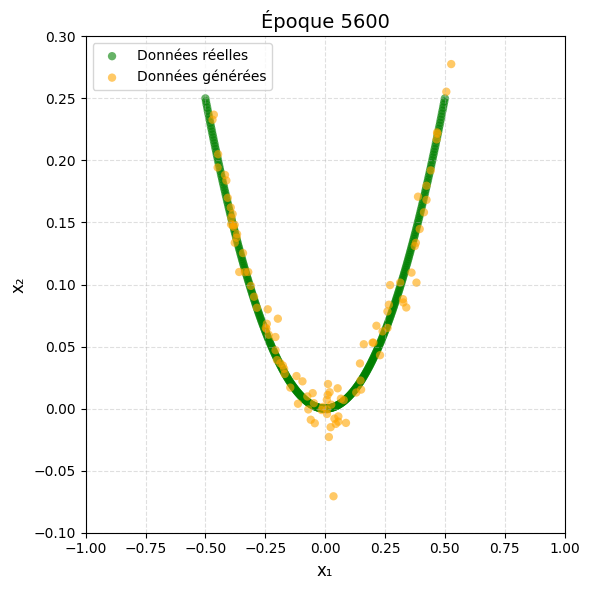

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


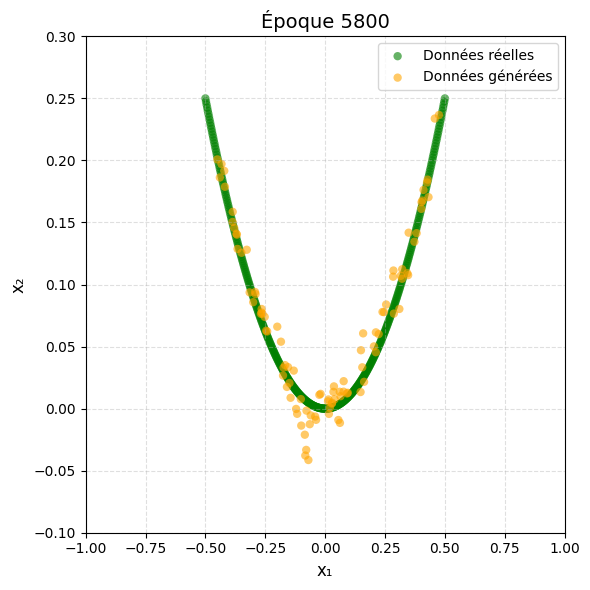

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


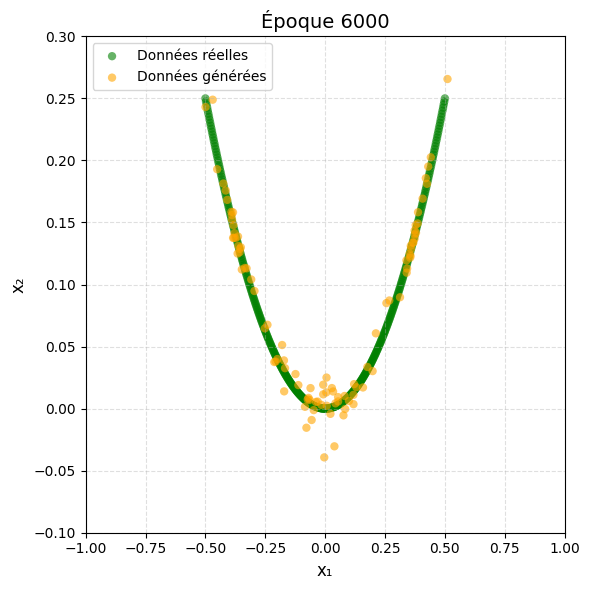

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step  


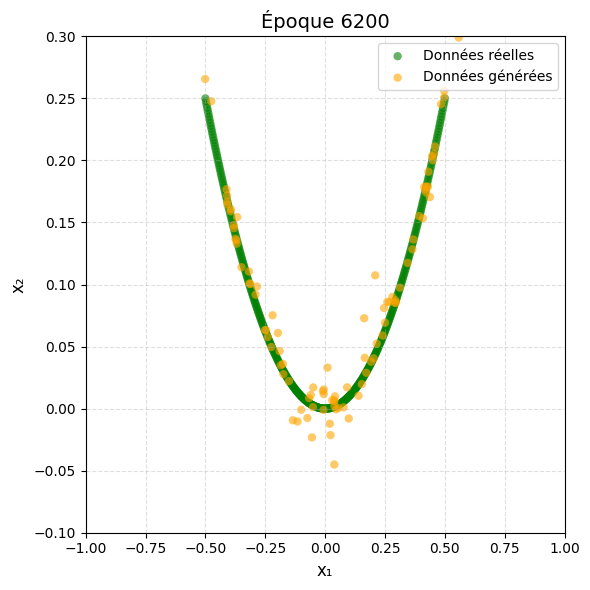

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


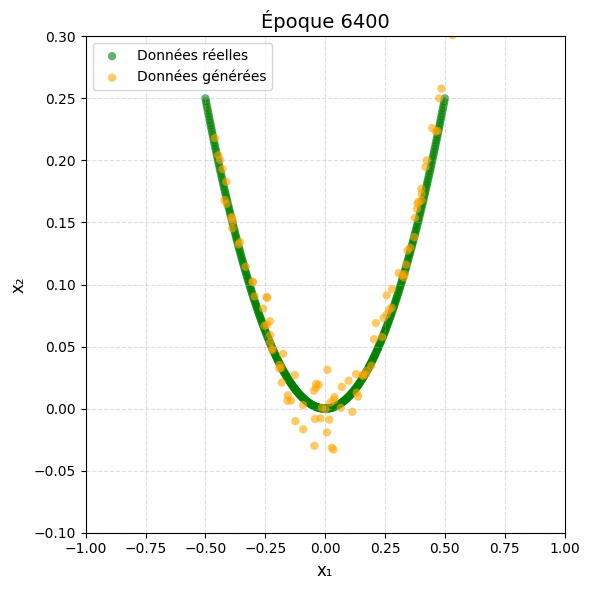

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


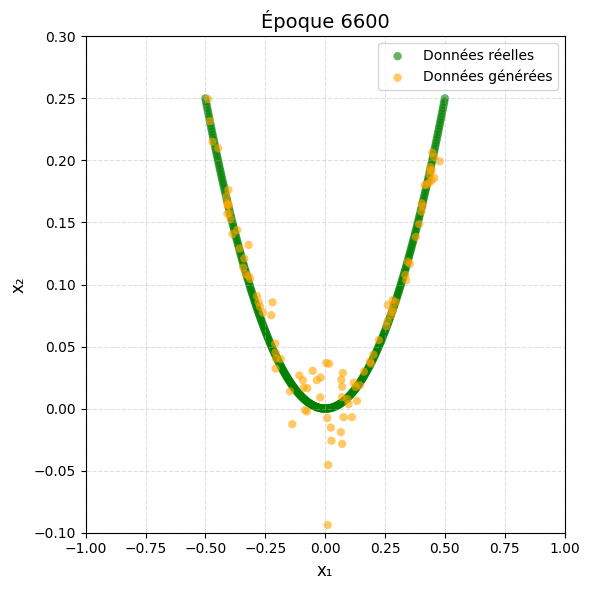

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


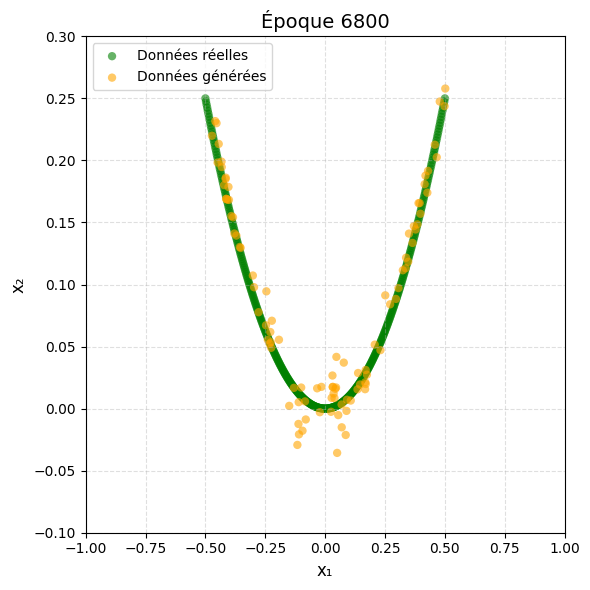

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step  


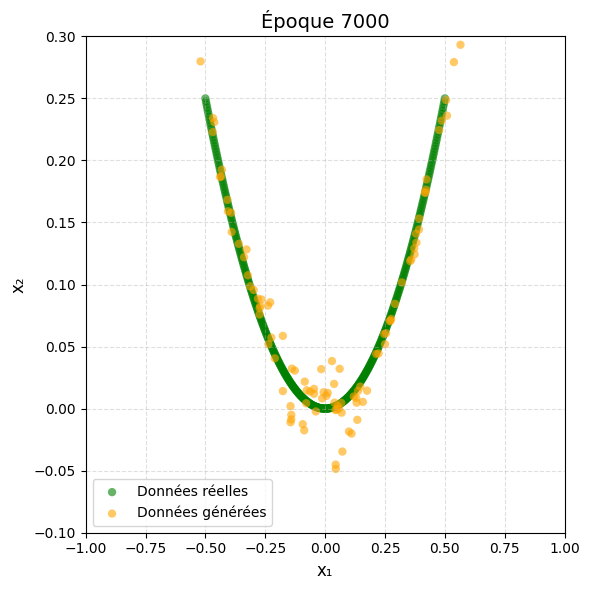

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


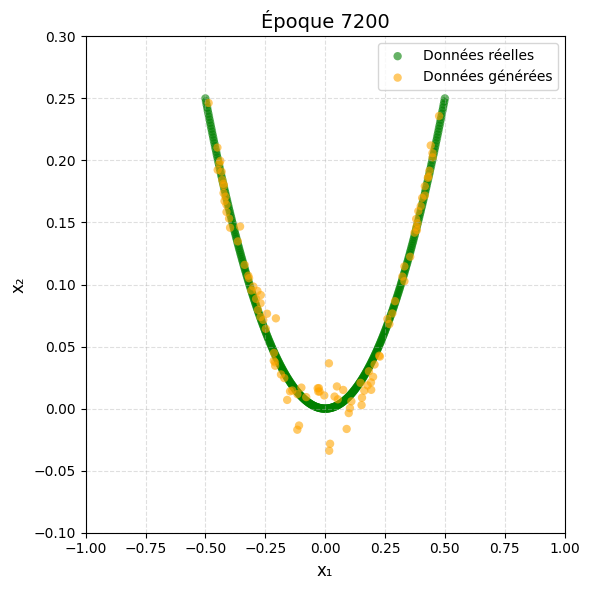

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


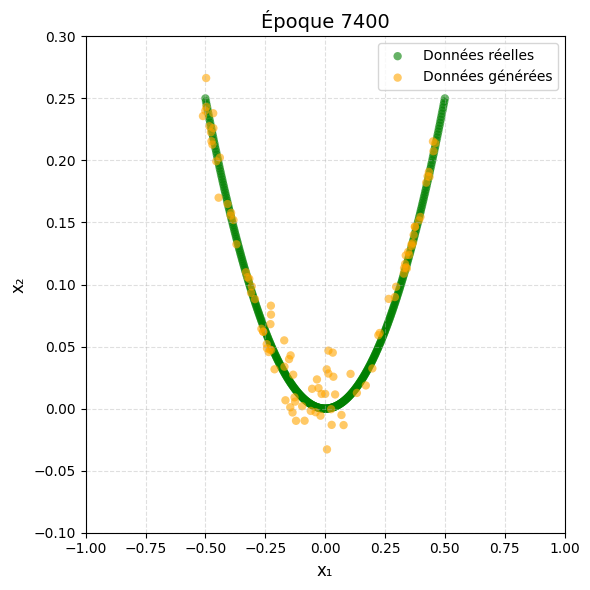

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


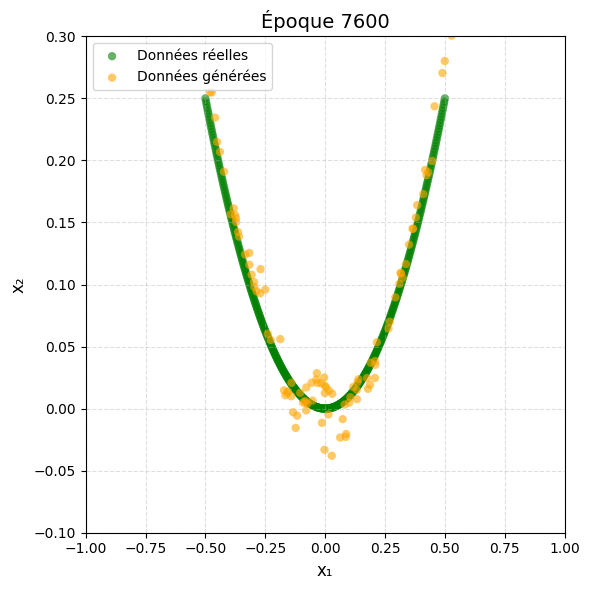

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


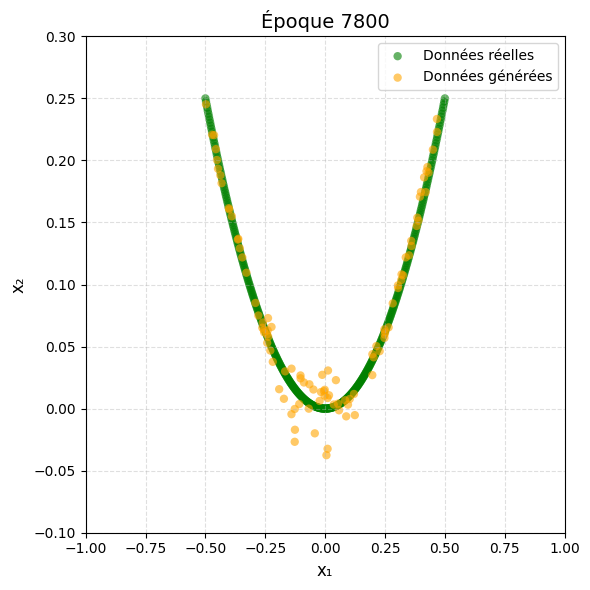

In [8]:
import matplotlib.pyplot as plt

N_epoch = 8000
batch_size = 128

y_train_gan = np.ones(shape=(batch_size, 1))

y_test_real = np.linspace(-0.5, 0.5, 400).reshape(400, 1)
y_test_real = np.hstack([y_test_real, y_test_real**2])

for epoch in range(N_epoch):
    X_batch_real, y_batch_real = generate_real_sample(n_input=batch_size)
    X_batch_fake, y_batch_fake = generate_fake_sample(generateur=generateur, latent_dim=espace_latent, n_input=batch_size)

    classifieur.train_on_batch(x=X_batch_real, y=y_batch_real)
    classifieur.train_on_batch(x=X_batch_fake, y=y_batch_fake)

    classifieur.trainable = False
    x_train_gan = np.random.normal(0, 1, size=(batch_size, espace_latent))
    gan.train_on_batch(x=x_train_gan, y=y_train_gan)
    classifieur.trainable = True

    if epoch % 200 == 0:
        x_test_gan = np.random.normal(0, 1, size=(100, espace_latent))
        x_fake_test = generateur.predict(x=x_test_gan)

        plt.figure(figsize=(6, 6))
        plt.title(f"Époque {epoch}", fontsize=14)
        plt.scatter(
            y_test_real[:, 0], y_test_real[:, 1],
            c="green", label="Données réelles", alpha=0.6, edgecolor="none"
        )
        plt.scatter(
            x_fake_test[:, 0], x_fake_test[:, 1],
            c="orange", label="Données générées", alpha=0.6, edgecolor="none"
        )
        plt.legend(frameon=True)
        plt.xlabel("x₁", fontsize=12)
        plt.ylabel("x₂", fontsize=12)
        plt.xlim(-1, 1)
        plt.ylim(-0.1, 0.3)
        plt.grid(True, linestyle="--", alpha=0.4)
        plt.tight_layout()
        plt.show()